***Hg Wavelength Calibration***

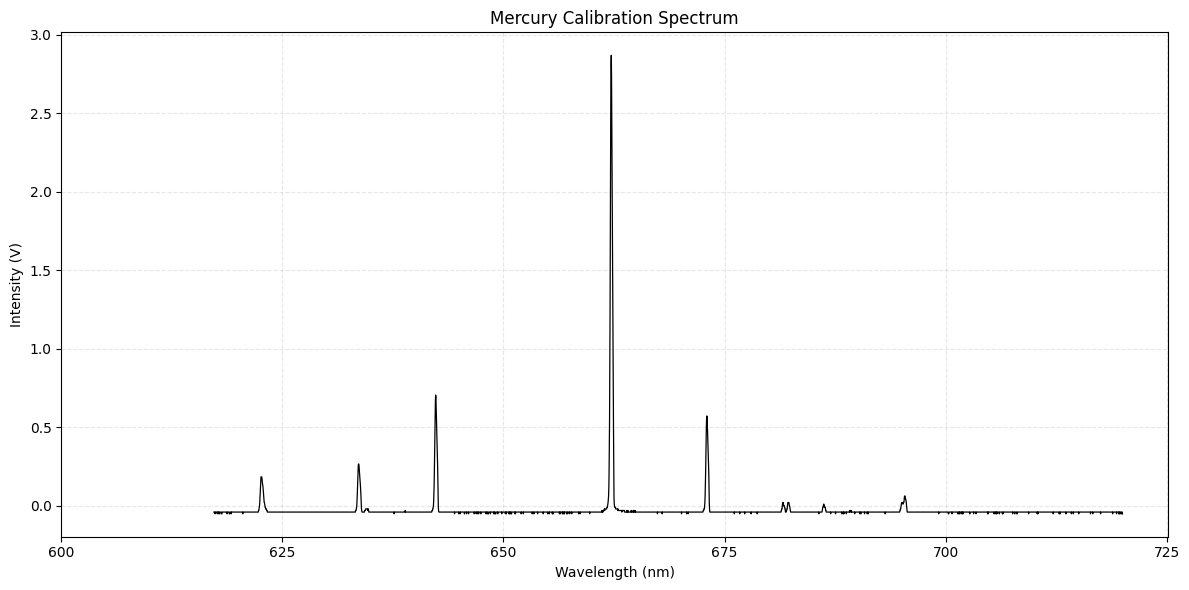

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# ----------- Load file -----------
fname = "15Uhr03_FP_Ba11_Hg_Spectrum.dat"

with open(fname, "r", encoding="utf-8") as f:
    lines = f.readlines()

# ----------- Metadata -----------
start_wavelength = float(lines[0].strip().replace(",", "."))
gear_factor      = float(lines[1].strip().replace(",", "."))
direction        = int(lines[2].strip())

# ----------- Read data -----------
data = []
for line in lines[3:]:
    line = line.strip()
    if not line:
        continue
    # German → English decimal
    line = line.replace(",", ".")
    parts = line.split()
    if len(parts) == 2:
        t, I = map(float, parts)
        data.append([t, I])

data = np.array(data)
t = data[:, 0]
I = -data[:, 1]     # flip sign → peaks point UP

# ----------- Reconstruct wavelength axis -----------
nm_per_s = gear_factor / 3.6   # conversion from manual

if direction == 1:
    wl_raw = start_wavelength + nm_per_s * t
else:
    wl_raw = start_wavelength - nm_per_s * t

# We want **short → long** wavelength left-to-right.
# If needed, flip wavelength axis AND intensity accordingly.
if wl_raw[0] > wl_raw[-1]:   # decreasing? → flip
    wavelength = wl_raw[::-1]
    intensity  = I[::-1]
else:
    wavelength = wl_raw
    intensity  = I

# ----------- Plot -----------
plt.figure(figsize=(12, 6))
plt.plot(wavelength, intensity, linewidth=0.9, color="black")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity (V)")
plt.title("Mercury Calibration Spectrum")

# Nice xticks every 25 nm (or change to what you want)
xmin = np.floor(min(wavelength) / 25) * 25
xmax = np.ceil(max(wavelength) / 25) * 25
plt.xticks(np.arange(xmin, xmax + 1, 25))

# Helpful grid
plt.grid(alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()
